In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os.path as op
from stress_risk.behavior.utils import get_data, build_model #, plot_ppc
import os

bids_folder = '/Users/mrenke/data/ds-stressrisk'

model_folder = op.join(bids_folder, 'derivatives', 'cogmodels')


/Users/mrenke/mambaforge/envs/behav_fit2_copy/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/behav_fit2_copy/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import arviz as az
n_model = 1
idata= az.from_netcdf(op.join(model_folder, f'model-{n_model}_trace.netcdf'))


In [3]:
idata.posterior

<xarray.Dataset>
Dimensions:                     (chain: 4, draw: 1000,
                                 n1_evidence_sd_regressors: 4, subject: 50,
                                 n2_evidence_sd_regressors: 4,
                                 risky_prior_mu_regressors: 4,
                                 risky_prior_std_regressors: 4,
                                 safe_prior_mu_regressors: 4,
                                 safe_prior_std_regressors: 4, p_dim_0: 11777)
Coordinates:
  * chain                       (chain) int64 0 1 2 3
  * draw                        (draw) int64 0 1 2 3 4 5 ... 995 996 997 998 999
  * n1_evidence_sd_regressors   (n1_evidence_sd_regressors) object 'Intercept...
  * subject                     (subject) int64 1 2 3 4 5 9 ... 55 57 58 59 61
  * n2_evidence_sd_regressors   (n2_evidence_sd_regressors) object 'Intercept...
  * risky_prior_mu_regressors   (risky_prior_mu_regressors) object 'Intercept...
  * risky_prior_std_regressors  (risky_prior_std_regressors) object 'Intercep...
  * safe_prior_mu_regressors    (safe_prior_mu_regressors) object 'Intercept'...
  * safe_prior_std_regressors   (safe_prior_std_regressors) object 'Intercept...
  * p_dim_0                     (p_dim_0) int64 0 1 2 3 ... 11774 11775 11776
Data variables: (12/25)
    n1_evidence_sd_mu           (chain, draw, n1_evidence_sd_regressors) float64 ...
    n1_evidence_sd_offset       (chain, draw, subject, n1_evidence_sd_regressors) float64 ...
    n2_evidence_sd_mu           (chain, draw, n2_evidence_sd_regressors) float64 ...
    n2_evidence_sd_offset       (chain, draw, subject, n2_evidence_sd_regressors) float64 ...
    risky_prior_mu_mu           (chain, draw, risky_prior_mu_regressors) float64 ...
    risky_prior_mu_offset       (chain, draw, subject, risky_prior_mu_regressors) float64 ...
    ...                          ...
    n2_evidence_sd              (chain, draw, subject, n2_evidence_sd_regressors) float64 ...
    risky_prior_mu              (chain, draw, subject, risky_prior_mu_regressors) float64 ...
    risky_prior_std             (chain, draw, subject, risky_prior_std_regressors) float64 ...
    safe_prior_mu               (chain, draw, subject, safe_prior_mu_regressors) float64 ...
    safe_prior_std              (chain, draw, subject, safe_prior_std_regressors) float64 ...
    p                           (chain, draw, p_dim_0) float64 ...
Attributes:
    created_at:                 2023-01-16T09:18:07.550564
    arviz_version:              0.14.0
    inference_library:          pymc
    inference_library_version:  4.3.0
    sampling_time:              2535.2040569782257
    tuning_steps:               1000

In [4]:
risky_prior_mu_post = idata.posterior['risky_prior_mu'].to_dataframe()


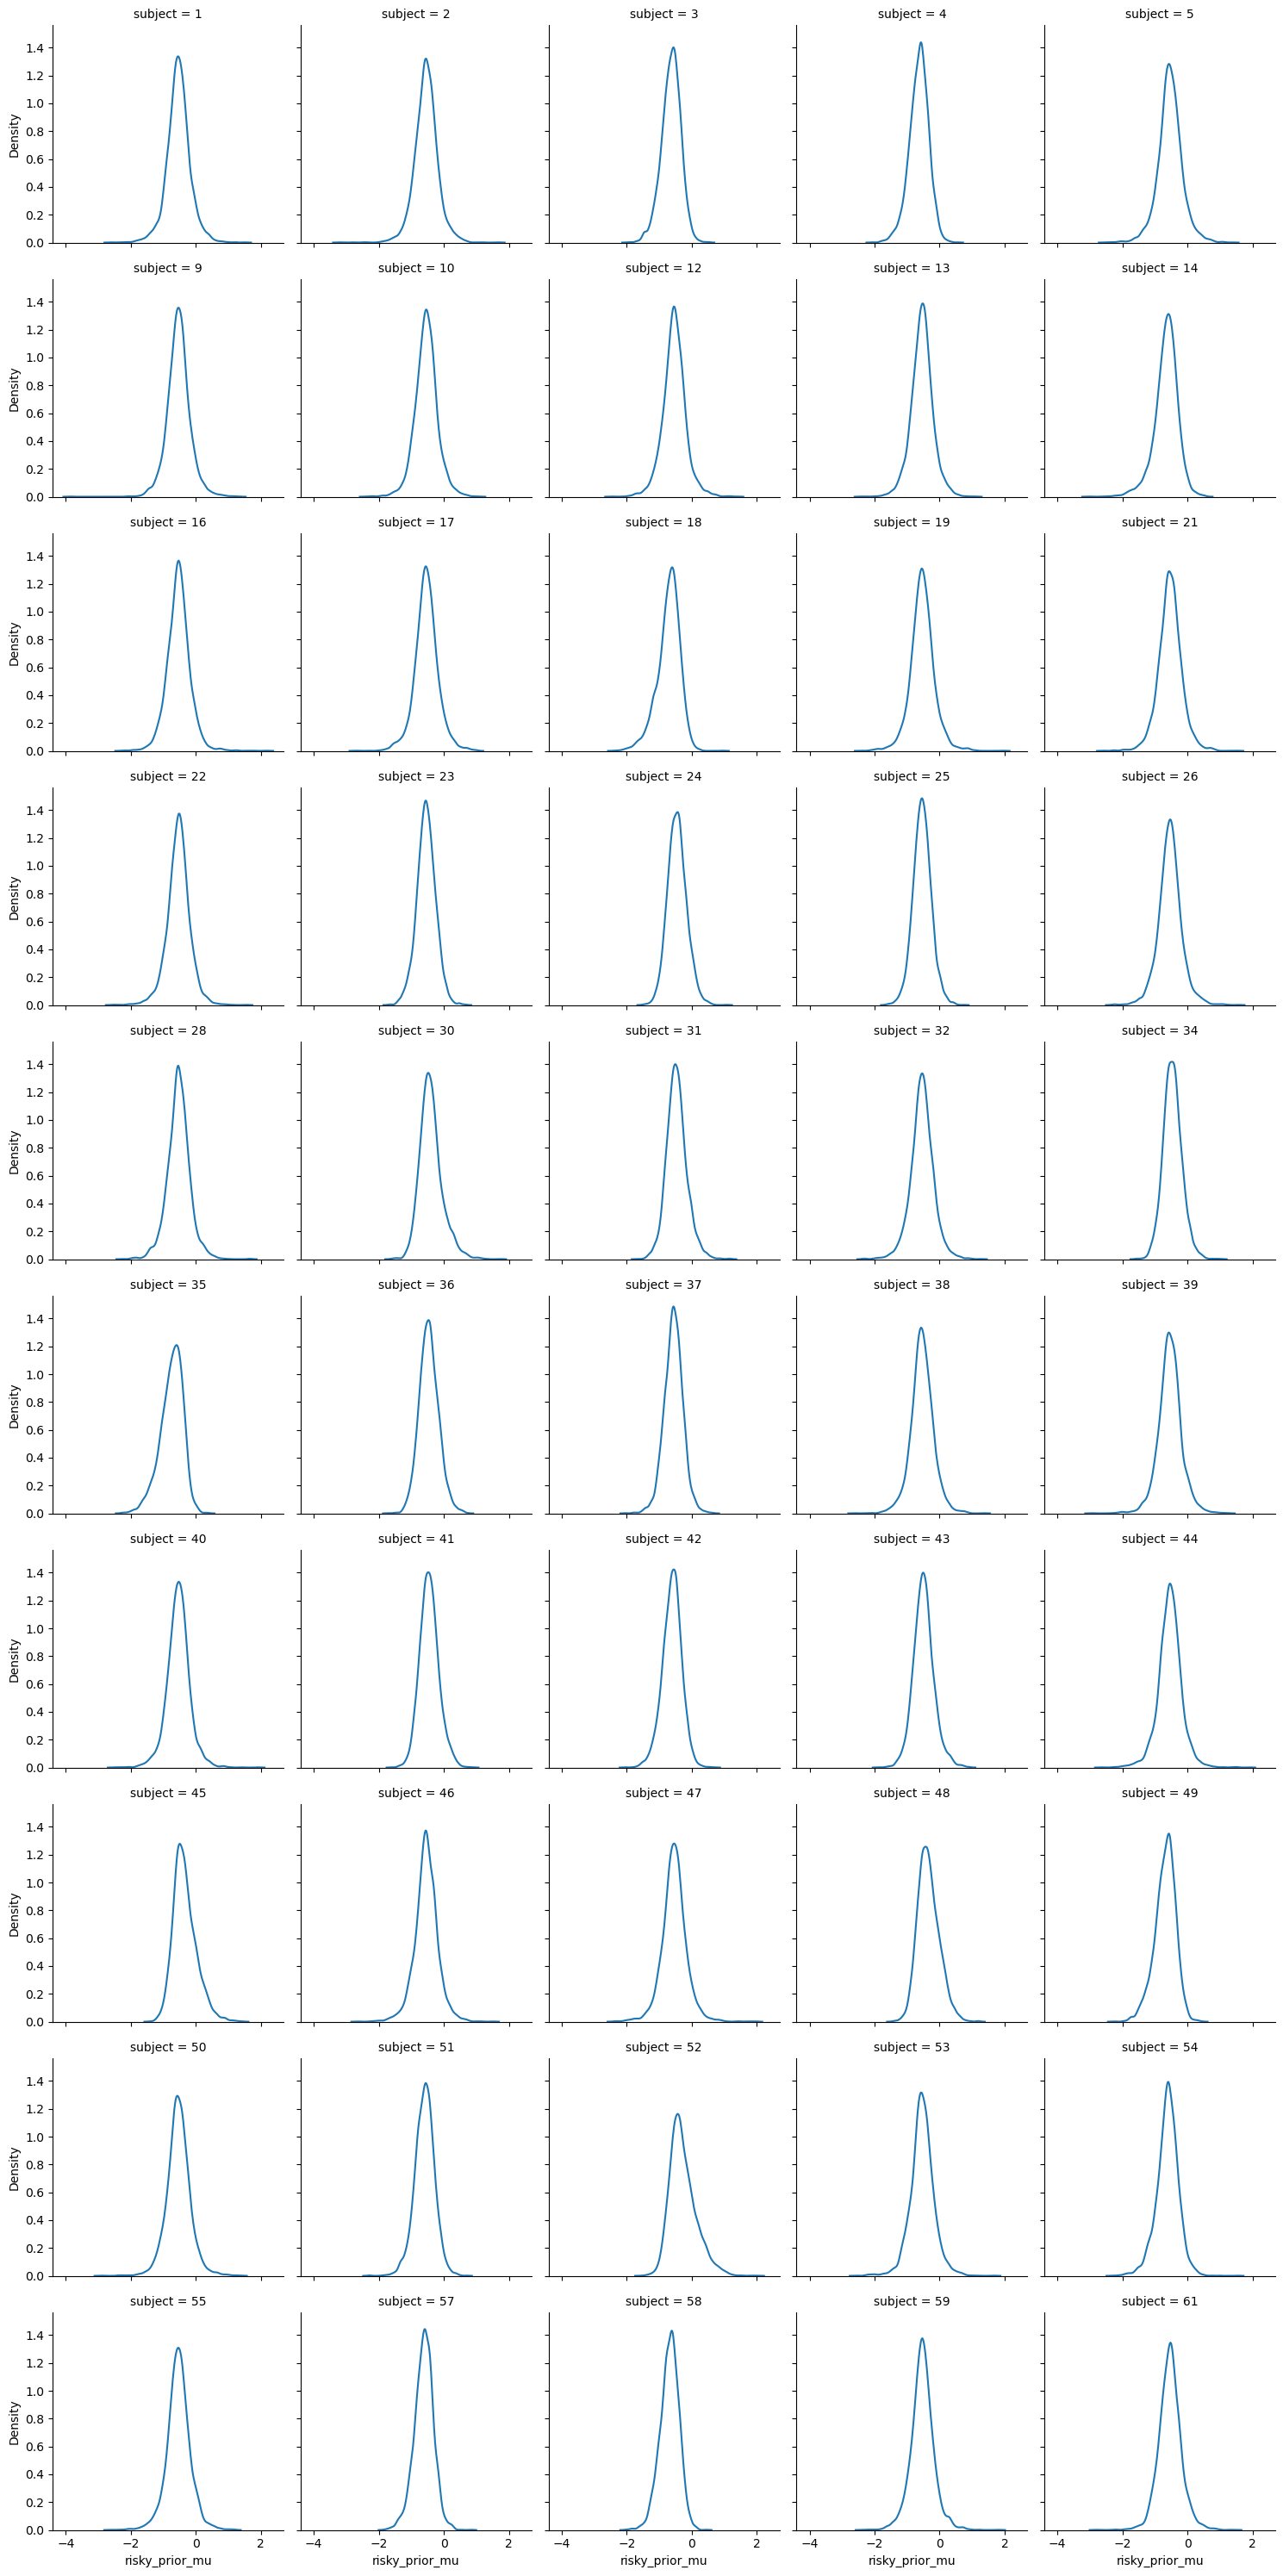

In [10]:
d = risky_prior_mu_post.xs('group', 0, 'risky_prior_mu_regressors')

fac = sns.FacetGrid(d.reset_index(), col='subject', col_wrap=5)

fac.map(sns.kdeplot, 'risky_prior_mu')

In [8]:
def softplus_np(x): return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0)
rpmu = risky_prior_mu_post.reset_index()
df_rpmu = softplus_np(rpmu[rpmu['risky_prior_mu_regressors']=='Intercept'].groupby(['subject']).mean())


KeyError: 'session'